# Importing libraries

In [82]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset

In [83]:
titanic_data = pd.read_csv('Titanic-Dataset.csv')
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [84]:
# Check df info
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [85]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [86]:
# Check for null values
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [87]:
# Since the 'Cabin' column has a large number of null values, we will drop it from the dataset
titanic_data.drop(columns=['Cabin'], inplace=True)

In [88]:
# Fill the null values in the 'Age' column with the mean age
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)

C:\Users\fierr\AppData\Local\Temp\ipykernel_12516\2602932734.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)


In [89]:
print(titanic_data['Embarked'].value_counts())

# Fill the null values in the 'Embarked' column with the most common value (mode)
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


C:\Users\fierr\AppData\Local\Temp\ipykernel_12516\2025001090.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)


In [90]:
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1

In [91]:
titanic_data.drop(columns=['Name','SibSp','Parch','Ticket'], inplace=True)

In [92]:
# Convert FamilySize to categorical variable
def family_size_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 5:
        return 'Small'
    else:
        return 'Large'

In [93]:
titanic_data['FamilySize'] = titanic_data['FamilySize'].apply(family_size_category)

In [94]:
# Check for null values again to confirm that they have been handled
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [95]:
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,1,0,3,male,22.0,7.2500,S,Small
1,2,1,1,female,38.0,71.2833,C,Small
2,3,1,3,female,26.0,7.9250,S,Alone
3,4,1,1,female,35.0,53.1000,S,Small
4,5,0,3,male,35.0,8.0500,S,Alone


In [96]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   Fare         891 non-null    float64
 6   Embarked     891 non-null    object 
 7   FamilySize   891 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB


In [97]:
# Convert 'Age' column to integer type
titanic_data['Age'] = titanic_data['Age'].astype('int64')

In [98]:
# Analyze survival correlation with categorical features
col = ['Embarked','Pclass','Sex','FamilySize']
for i in col:
    print('Survival correlation by: ',i)
    titanic_data2 = titanic_data.groupby(i)['Survived'].mean().reset_index()
    print(titanic_data2)

Survival correlation by:  Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
Survival correlation by:  Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
Survival correlation by:  Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
Survival correlation by:  FamilySize
  FamilySize  Survived
0      Alone  0.303538
1      Large  0.148936
2      Small  0.560261


# Visualization 

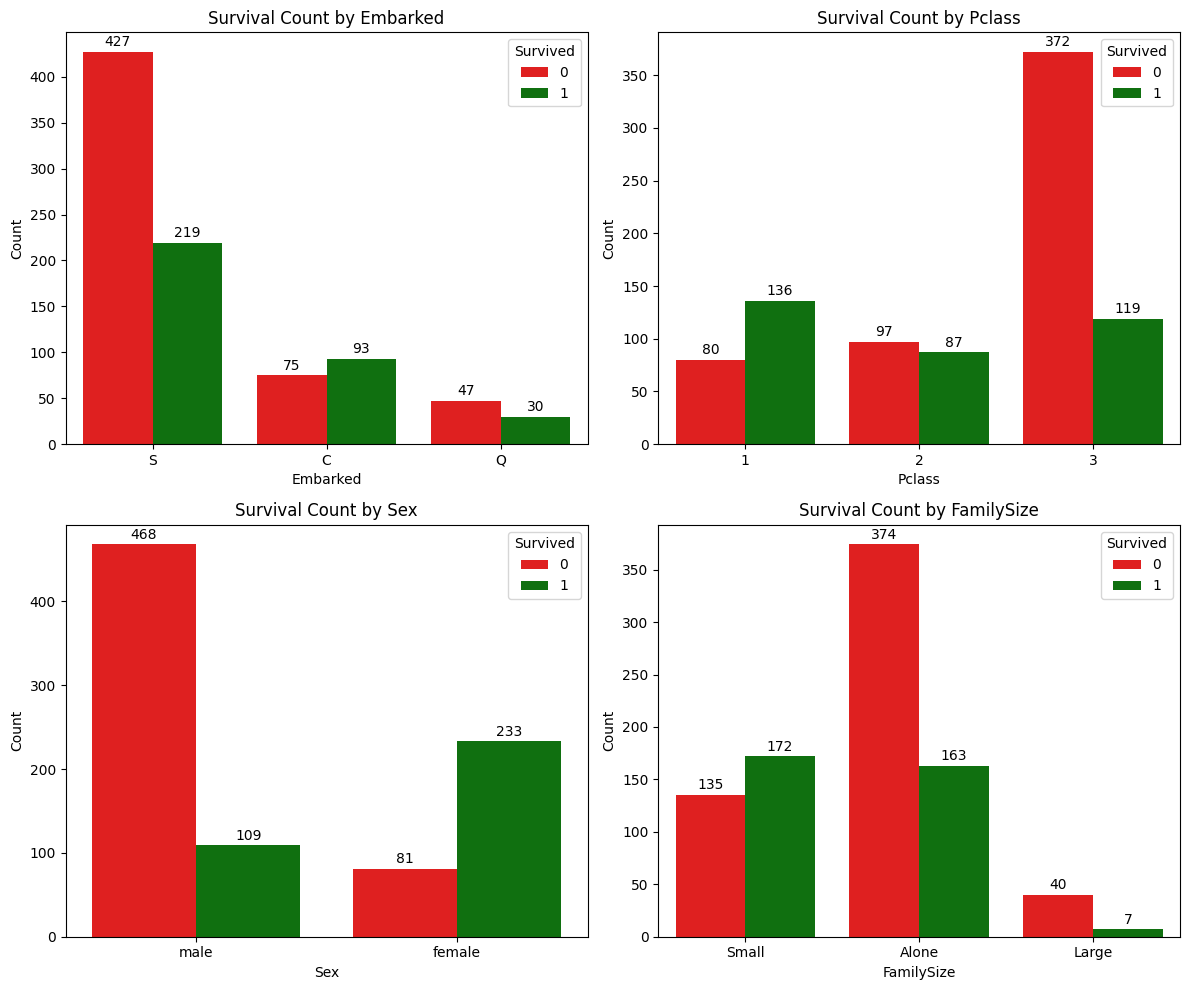

In [99]:
# Visualize the number of survivors and non-survivors by features
plt.figure(figsize=(12, 10))
for i, feature in enumerate(col):
    colors = ['red', 'green']
    ax = plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='Survived', data=titanic_data, palette=colors, ax=ax)
    plt.title(f'Survival Count by {feature}')
    plt.ylabel('Count')
    plt.xlabel(feature)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=2)
plt.tight_layout()
plt.show()

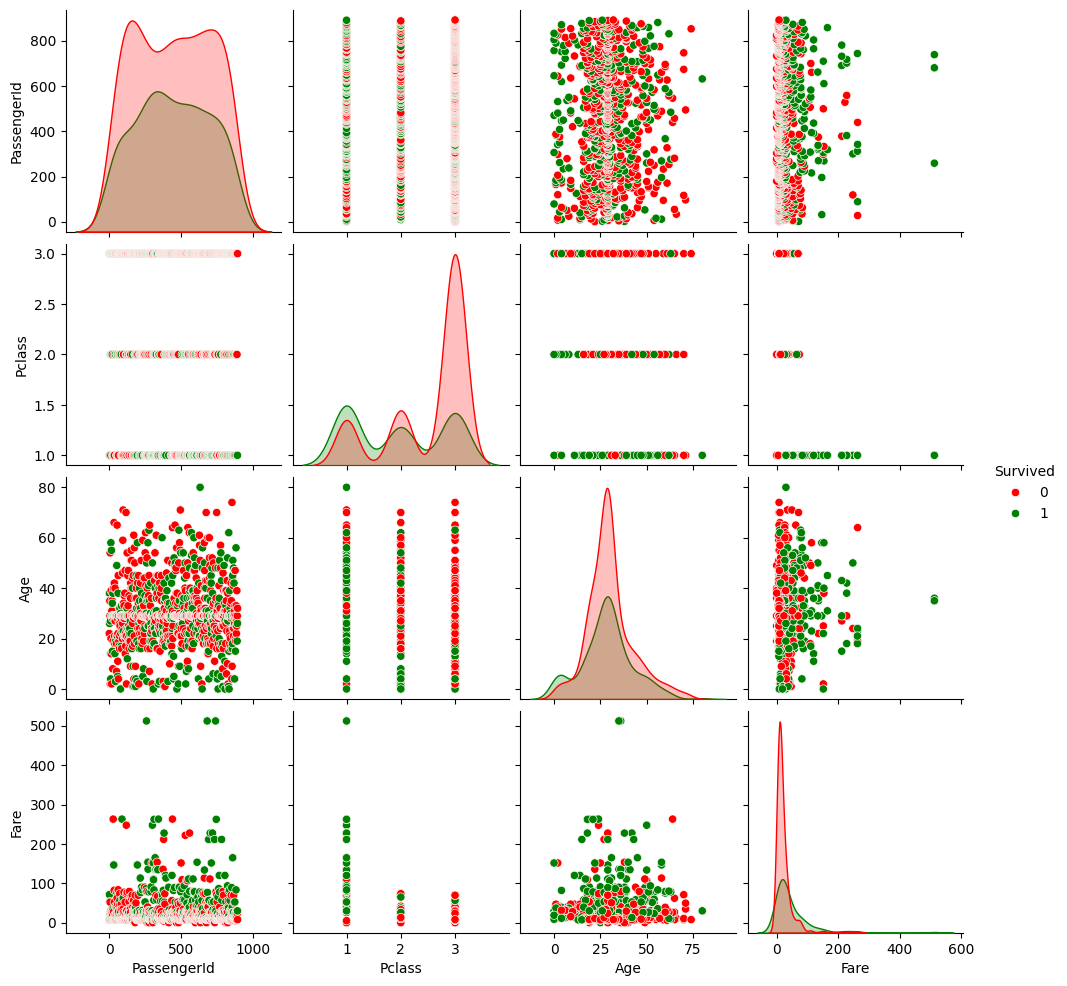

In [106]:
colors = ['red', 'green']
sns.pairplot(titanic_data, hue='Survived', palette=colors)